Exploratory Data Analysis & Key Insights Summary
Regional Impact: Tripura and Haryana exhibited the highest average unemployment rates across India, both exceeding 25%.

Temporal Trend & Lockdown Spike: Unemployment rates remained relatively stable under 12% until April–May 2020, where a severe spike occurred due to nationwide COVID-19 lockdowns.

Pre-COVID vs. Post-COVID Comparison: The average nationwide unemployment rate nearly doubled, jumping from 9.51% prior to March 2020 to 17.77% in the post-lockdown period.

Metric Correlation: A negative correlation (-0.22) exists between the number of employed individuals and the unemployment rate, while the Labour Participation Rate shows almost zero linear impact on unemployment (0.00).

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None

--- Missing Values ---
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Ra

/tmp/ipykernel_3923/168386784.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Region', y='Unemployment_Rate', data=df, ci=None, palette='viridis')
/tmp/ipykernel_3923/168386784.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Unemployment_Rate', data=df, ci=None, palette='viridis')


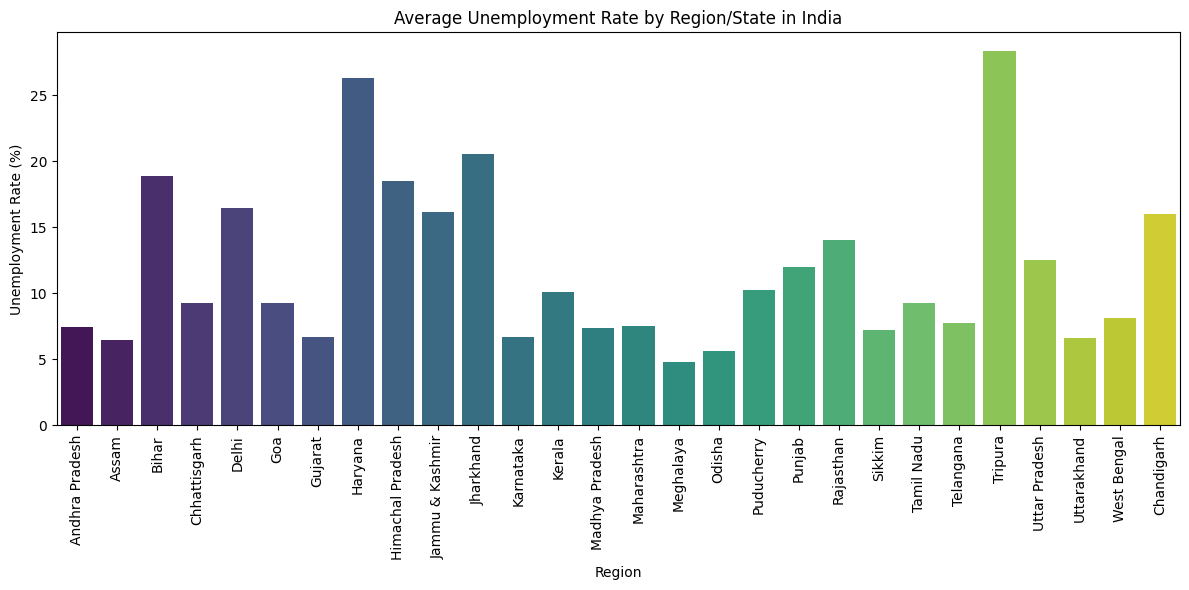

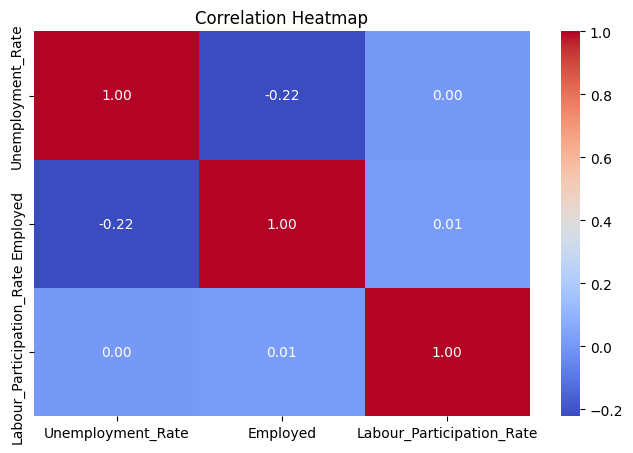

In [ ]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract uploaded zip file automatically
zip_files = [f for f in os.listdir('.') if f.endswith('.zip')]
if zip_files:
    with zipfile.ZipFile(zip_files[0], 'r') as zip_ref:
        zip_ref.extractall('.')

# 2. Identify and Load CSV File
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
df = pd.read_csv(csv_files[0])

# 3. Clean Column Names (remove leading/trailing spaces)
df.columns = df.columns.str.strip()

# 4. Data Inspection & Cleaning
print("--- Dataset Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Drop rows with null values if present
df.dropna(inplace=True)

# 5. Rename key columns for simplicity
# Dataset columns vary slightly across versions, so we rename safely
rename_dict = {}
for col in df.columns:
    if 'Estimated Unemployment Rate' in col:
        rename_dict[col] = 'Unemployment_Rate'
    elif 'Estimated Employed' in col:
        rename_dict[col] = 'Employed'
    elif 'Estimated Labour Participation' in col:
        rename_dict[col] = 'Labour_Participation_Rate'
    elif 'Region' in col:
        rename_dict[col] = 'Region'

df.rename(columns=rename_dict, inplace=True)

# 6. Bar Plot: Unemployment Rate by Region/State
plt.figure(figsize=(12, 6))
sns.barplot(x='Region', y='Unemployment_Rate', data=df, ci=None, palette='viridis')
plt.xticks(rotation=90)
plt.title('Average Unemployment Rate by Region/State in India')
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

# 7. Heatmap: Correlation between features
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

/tmp/ipykernel_3923/1603284868.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Unemployment_Rate', y='Region', data=top10, palette='magma')


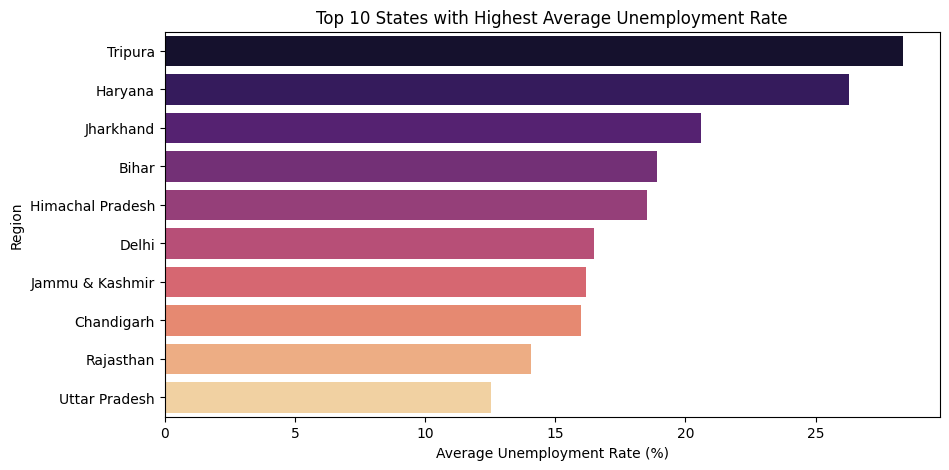

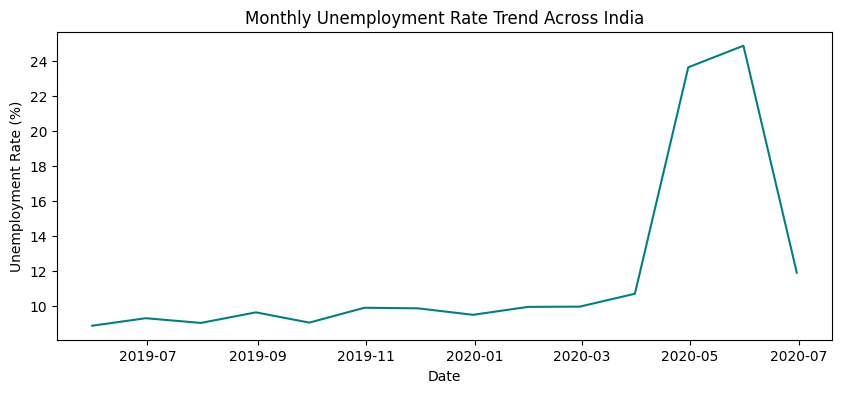

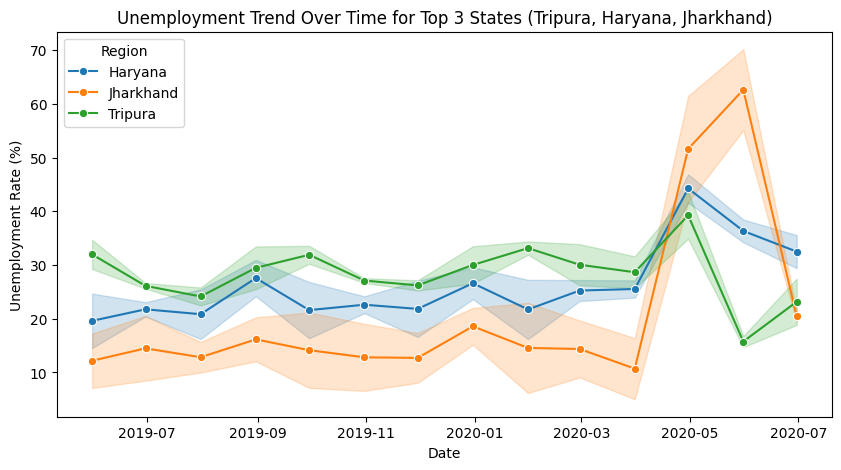

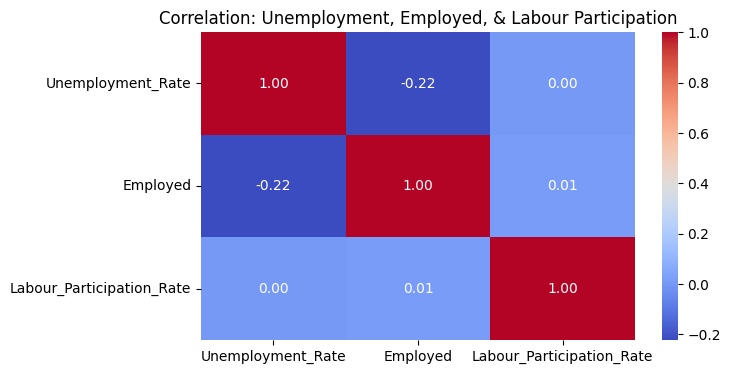


--- Pre-COVID vs Post-COVID Mean Rates ---
            Unemployment_Rate      Employed  Labour_Participation_Rate
Period                                                                
Post-COVID          17.774363  6.517203e+06                  39.330049
Pre-COVID            9.509534  7.466028e+06                  43.886119


/tmp/ipykernel_3923/1603284868.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Period', y='Unemployment_Rate', data=df, ci=None, palette='Set2')
/tmp/ipykernel_3923/1603284868.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Unemployment_Rate', data=df, ci=None, palette='Set2')


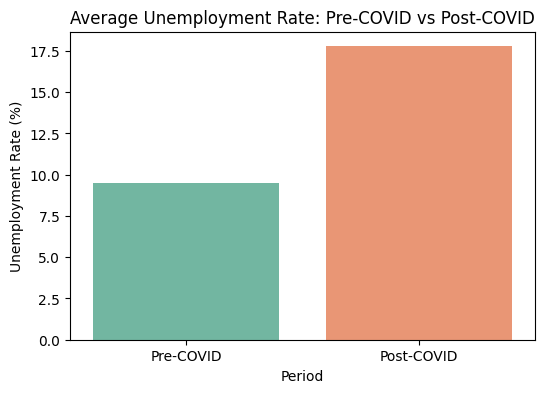

In [ ]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract & Load Data
zip_files = [f for f in os.listdir('.') if f.endswith('.zip')]
if zip_files:
    with zipfile.ZipFile(zip_files[0], 'r') as zip_ref:
        zip_ref.extractall('.')

csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
df = pd.read_csv(csv_files[0])

# Clean column names
df.columns = df.columns.str.strip()
df.dropna(inplace=True)

# Rename columns safely
rename_dict = {}
for col in df.columns:
    if 'Estimated Unemployment Rate' in col:
        rename_dict[col] = 'Unemployment_Rate'
    elif 'Estimated Employed' in col:
        rename_dict[col] = 'Employed'
    elif 'Estimated Labour Participation' in col:
        rename_dict[col] = 'Labour_Participation_Rate'
    elif 'Region' in col:
        rename_dict[col] = 'Region'
    elif 'Date' in col:
        rename_dict[col] = 'Date'

df.rename(columns=rename_dict, inplace=True)

# Format Date column for temporal analysis
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

# --- 1. Top 10 States with Highest Unemployment Rate ---
plt.figure(figsize=(10, 5))
top10 = df.groupby('Region')['Unemployment_Rate'].mean().nlargest(10).reset_index()
sns.barplot(x='Unemployment_Rate', y='Region', data=top10, palette='magma')
plt.title('Top 10 States with Highest Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.show()

# --- 2. Month-Wise Trends ---
plt.figure(figsize=(10, 4))
sns.lineplot(x='Date', y='Unemployment_Rate', data=df, errorbar=None, color='teal')
plt.title('Monthly Unemployment Rate Trend Across India')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.show()

# --- 3. Time-Series Line Chart for Major States ---
top_3_states = df.groupby('Region')['Unemployment_Rate'].mean().nlargest(3).index.tolist()
df_top3 = df[df['Region'].isin(top_3_states)]

plt.figure(figsize=(10, 5))
sns.lineplot(x='Date', y='Unemployment_Rate', hue='Region', data=df_top3, marker='o')
plt.title(f'Unemployment Trend Over Time for Top 3 States ({", ".join(top_3_states)})')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.show()

# --- 4. Heatmap: Feature Correlation ---
plt.figure(figsize=(7, 4))
sns.heatmap(df[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Unemployment, Employed, & Labour Participation')
plt.show()

# --- 5. Pre-COVID vs Post-COVID Comparison ---
# Lockdown impact split point (~March 2020)
covid_date = pd.to_datetime('2020-03-01')
df['Period'] = df['Date'].apply(lambda x: 'Pre-COVID' if x < covid_date else 'Post-COVID')

print("\n--- Pre-COVID vs Post-COVID Mean Rates ---")
print(df.groupby('Period')[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].mean())

plt.figure(figsize=(6, 4))
sns.barplot(x='Period', y='Unemployment_Rate', data=df, ci=None, palette='Set2')
plt.title('Average Unemployment Rate: Pre-COVID vs Post-COVID')
plt.ylabel('Unemployment Rate (%)')
plt.show()